# Plant Leaf Disease Classification 

step 1: accquiring the dataset

lets first import the necessary libraries

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50, DenseNet121, EfficientNetB0
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.metrics import classification_report, confusion_matrix

lets check the tensorflow version too

In [2]:
print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


now lets check the dataset location for the images

In [3]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/mohitsingh1804
/kaggle/input/datasets/mohitsingh1804/plantvillage
/kaggle/input/datasets/mohitsingh1804/plantvillage/PlantVillage
/kaggle/input/datasets/mohitsingh1804/plantvillage/PlantVillage/val
/kaggle/input/datasets/mohitsingh1804/plantvillage/PlantVillage/val/Tomato___Late_blight
/kaggle/input/datasets/mohitsingh1804/plantvillage/PlantVillage/val/Tomato___healthy
/kaggle/input/datasets/mohitsingh1804/plantvillage/PlantVillage/val/Grape___healthy
/kaggle/input/datasets/mohitsingh1804/plantvillage/PlantVillage/val/Orange___Haunglongbing_(Citrus_greening)
/kaggle/input/datasets/mohitsingh1804/plantvillage/PlantVillage/val/Soybean___healthy
/kaggle/input/datasets/mohitsingh1804/plantvillage/PlantVillage/val/Squash___Powdery_mildew
/kaggle/input/datasets/mohitsingh1804/plantvillage/PlantVillage/val/Potato___healthy
/kaggle/input/datasets/mohitsingh1804/plantvillage/PlantVillage/val/Corn_(maize)___Northern_Leaf_Blight
/kaggle/

KeyboardInterrupt: 

okay we got the location

In [4]:
train_dir = "/kaggle/input/datasets/mohitsingh1804/plantvillage/PlantVillage/train"
val_dir = "/kaggle/input/datasets/mohitsingh1804/plantvillage/PlantVillage/val"

print("Training Path:", train_dir)
print("Validation Path:", val_dir)

Training Path: /kaggle/input/datasets/mohitsingh1804/plantvillage/PlantVillage/train
Validation Path: /kaggle/input/datasets/mohitsingh1804/plantvillage/PlantVillage/val


lets check the number of classes

In [5]:
classes = sorted(os.listdir(train_dir))

print("Number of Classes:", len(classes))
print(classes)

Number of Classes: 38
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite

now thats a lot of classes 38

# creating the data generators

In [6]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 43444 images belonging to 38 classes.
Found 10861 images belonging to 38 classes.


lets verify the data

In [7]:
print("Training Images :", train_generator.samples)
print("Validation Images :", val_generator.samples)

print("\nNumber of Classes :", train_generator.num_classes)
print("\nClass Indices:")
print(train_generator.class_indices)

Training Images : 43444
Validation Images : 10861

Number of Classes : 38

Class Indices:
{'Apple___Apple_scab': 0, 'Apple___Black_rot': 1, 'Apple___Cedar_apple_rust': 2, 'Apple___healthy': 3, 'Blueberry___healthy': 4, 'Cherry_(including_sour)___Powdery_mildew': 5, 'Cherry_(including_sour)___healthy': 6, 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 7, 'Corn_(maize)___Common_rust_': 8, 'Corn_(maize)___Northern_Leaf_Blight': 9, 'Corn_(maize)___healthy': 10, 'Grape___Black_rot': 11, 'Grape___Esca_(Black_Measles)': 12, 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 13, 'Grape___healthy': 14, 'Orange___Haunglongbing_(Citrus_greening)': 15, 'Peach___Bacterial_spot': 16, 'Peach___healthy': 17, 'Pepper,_bell___Bacterial_spot': 18, 'Pepper,_bell___healthy': 19, 'Potato___Early_blight': 20, 'Potato___Late_blight': 21, 'Potato___healthy': 22, 'Raspberry___healthy': 23, 'Soybean___healthy': 24, 'Squash___Powdery_mildew': 25, 'Strawberry___Leaf_scorch': 26, 'Strawberry___healthy': 27, 'Toma

# visualisation of the dataset

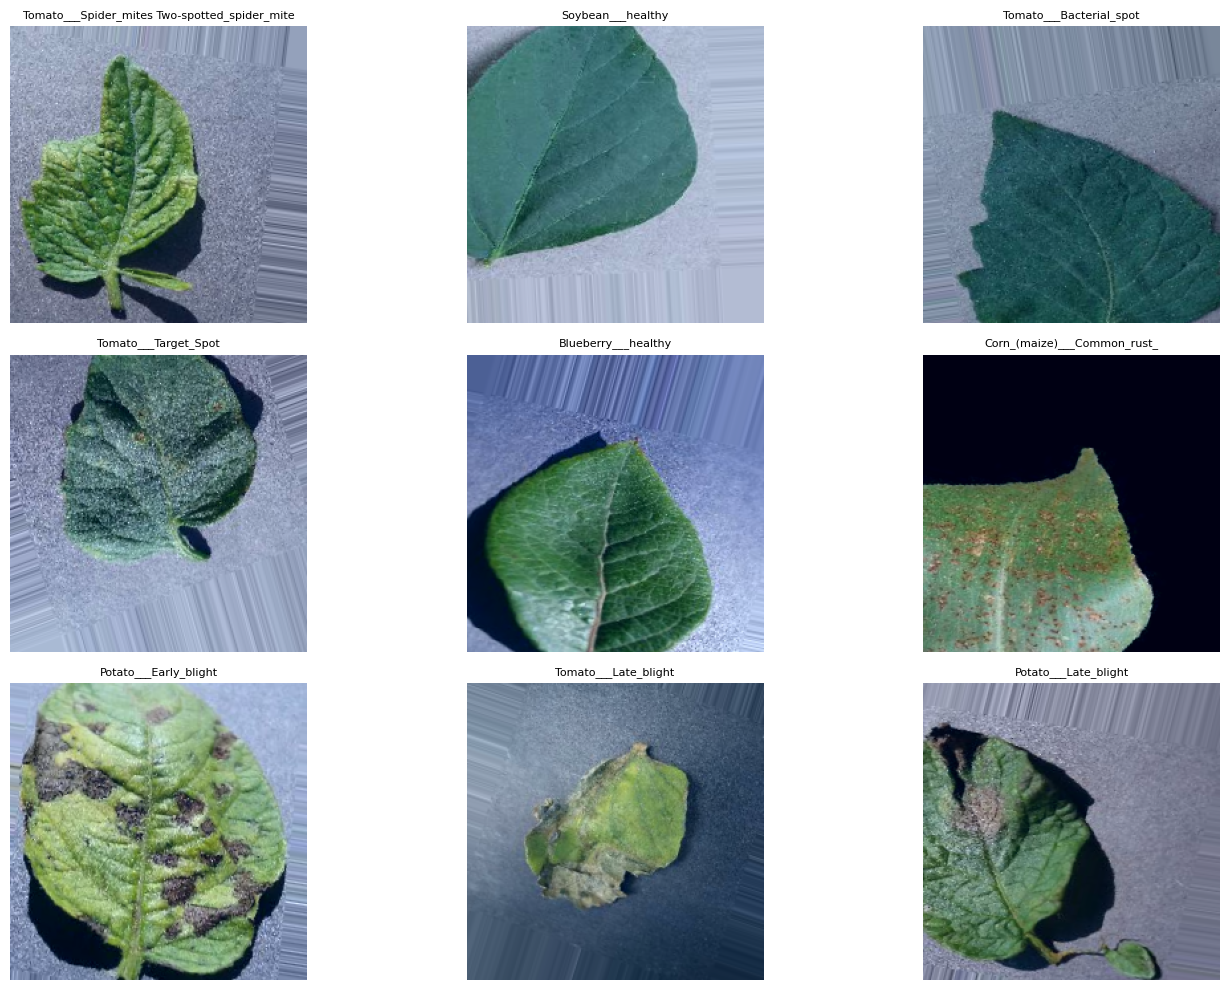

In [8]:
# Display a batch of training images

images, labels = next(train_generator)

plt.figure(figsize=(15, 10))

for i in range(9):
    plt.subplot(3, 3, i + 1)

    # Undo ResNet50 preprocessing for display
    img = images[i].copy()
    img = img[..., ::-1]          # BGR → RGB
    img = img + [103.939, 116.779, 123.68]
    img = np.clip(img / 255.0, 0, 1)

    plt.imshow(img)
    plt.title(list(train_generator.class_indices.keys())[np.argmax(labels[i])],
              fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()

now lets check the class weights so that we can see if every class is balanced or not

In [9]:
from sklearn.utils.class_weight import compute_class_weight

# Compute class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(2.268379281537176), 1: np.float64(2.3049660441426147), 2: np.float64(5.196650717703349), 3: np.float64(0.8687410014397696), 4: np.float64(0.9511340747876347), 5: np.float64(1.3577947243405426), 6: np.float64(1.6714373653431824), 7: np.float64(2.788446726572529), 8: np.float64(1.199646545534876), 9: np.float64(1.4508415709324072), 10: np.float64(1.2306384907370687), 11: np.float64(1.2110838537020518), 12: np.float64(1.0327580468787143), 13: np.float64(1.327831774558347), 14: np.float64(3.3724576929048284), 15: np.float64(0.2595376067865464), 16: np.float64(0.6220147757860375), 17: np.float64(3.9696637426900585), 18: np.float64(1.4344581654890047), 19: np.float64(0.966410108110513), 20: np.float64(1.4290789473684211), 21: np.float64(1.4290789473684211), 22: np.float64(9.448455850369726), 23: np.float64(3.849370902002481), 24: np.float64(0.28076207217454247), 25: np.float64(0.7787896170945073), 26: np.float64(1.2889099863525781), 27: np.float64(3.1408328513591672), 28: np.f

some observations: \
Class weights help the model pay more attention to minority classes instead of favoring the majority ones. \
0.8 – 1.2 → Well balanced


In [10]:
import pandas as pd

class_counts = pd.Series(train_generator.classes).value_counts().sort_index()

class_df = pd.DataFrame({
    "Class": list(train_generator.class_indices.keys()),
    "Images": class_counts.values,
    "Class Weight": [class_weights[i] for i in range(len(class_weights))]
})

class_df

,Class,Images,Class Weight
0,Apple___Apple_scab,504,2.268379
1,Apple___Black_rot,496,2.304966
2,Apple___Cedar_apple_rust,220,5.196651
3,Apple___healthy,1316,0.868741
4,Blueberry___healthy,1202,0.951134
5,Cherry_(including_sour)___Powdery_mildew,842,1.357795
6,Cherry_(including_sour)___healthy,684,1.671437
7,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,410,2.788447
8,Corn_(maize)___Common_rust_,953,1.199647
9,Corn_(maize)___Northern_Leaf_Blight,788,1.450842


this is an perfectly imblanced dataset so we will keep the class weights so that i can identify the minority classes

# Building the Resnet50 model

In [11]:
# Load ResNet50 without the top classifier
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze the pretrained layers
base_model.trainable = False

# Add custom classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)

outputs = Dense(
    train_generator.num_classes,
    activation='softmax'
)(x)

model = Model(inputs=base_model.input, outputs=outputs)

I0000 00:00:1783654600.911340      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


compile the model

In [12]:
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,777,894 (94.52 MB)

 Trainable params: 1,190,182 (4.54 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

callbacks for the model

In [13]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),

    ModelCheckpoint(
        'best_resnet50.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

In [14]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/10
   1/1358 ━━━━━━━━━━━━━━━━━━━━ 5:15:06 14s/step - accuracy: 0.0000e+00 - loss: 4.9133

I0000 00:00:1783654631.374578     150 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 582ms/step - accuracy: 0.4937 - loss: 1.8763
Epoch 1: val_accuracy improved from None to 0.91566, saving model to best_resnet50.keras

Epoch 1: finished saving model to best_resnet50.keras
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 912s 662ms/step - accuracy: 0.6507 - loss: 1.1986 - val_accuracy: 0.9157 - val_loss: 0.2499 - learning_rate: 0.0010
Epoch 2/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 406ms/step - accuracy: 0.8002 - loss: 0.6383
Epoch 2: val_accuracy improved from 0.91566 to 0.92137, saving model to best_resnet50.keras

Epoch 2: finished saving model to best_resnet50.keras
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 581s 428ms/step - accuracy: 0.8057 - loss: 0.6187 - val_accuracy: 0.9214 - val_loss: 0.2375 - learning_rate: 0.0010
Epoch 3/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step - accuracy: 0.8304 - loss: 0.5370
Epoch 3: val_accuracy improved from 0.92137 to 0.93693, saving model to best_resnet50.keras

Epoch 3: finished saving model to best_resnet50.keras
1358/1358

In [15]:
model.save("resnet50_stage1.keras")

wow training validation is 93% and validation accuracy is 95% its a strong start. now lets see its curves

In [16]:
val_loss, val_acc = model.evaluate(val_generator)

print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Validation Loss: {val_loss:.4f}")

340/340 ━━━━━━━━━━━━━━━━━━━━ 35s 103ms/step - accuracy: 0.9584 - loss: 0.1216
Validation Accuracy: 0.9584
Validation Loss: 0.1216


In [17]:
predictions = model.predict(val_generator)

y_pred = np.argmax(predictions, axis=1)
y_true = val_generator.classes

340/340 ━━━━━━━━━━━━━━━━━━━━ 34s 89ms/step


In [18]:
print(classification_report(
    y_true,
    y_pred,
    target_names=list(val_generator.class_indices.keys())
))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.98      0.94      0.96       126
                                 Apple___Black_rot       0.95      0.99      0.97       125
                          Apple___Cedar_apple_rust       0.96      0.98      0.97        55
                                   Apple___healthy       0.95      0.98      0.97       329
                               Blueberry___healthy       1.00      1.00      1.00       300
          Cherry_(including_sour)___Powdery_mildew       1.00      0.98      0.99       210
                 Cherry_(including_sour)___healthy       0.99      0.99      0.99       170
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.82      0.91      0.87       103
                       Corn_(maize)___Common_rust_       1.00      1.00      1.00       239
               Corn_(maize)___Northern_Leaf_Blight       0.95      0.90      0.

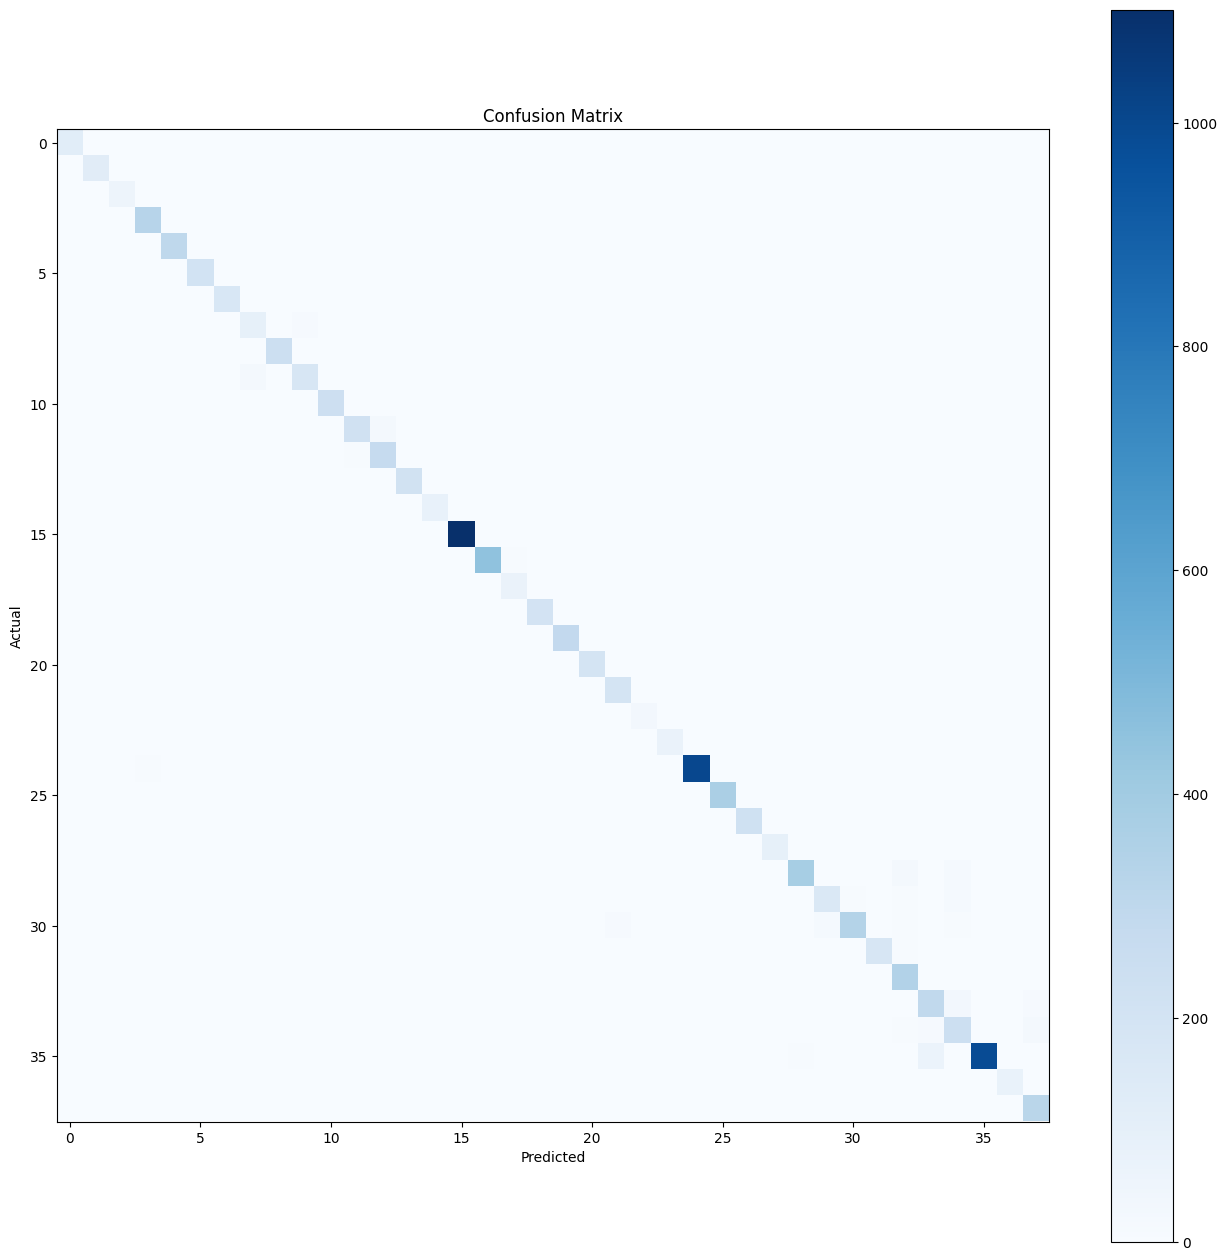

In [19]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(16,16))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

lets save the training history too

In [20]:
import pickle

with open("resnet50_stage1_history.pkl", "wb") as f:
    pickle.dump(history.history, f)

In [21]:
import json

with open("class_indices.json", "w") as f:
    json.dump(train_generator.class_indices, f)

# stage 2 of model - fine tuning

In [22]:
# Unfreeze the base model
base_model.trainable = True

# Freeze all layers except the last 50
for layer in base_model.layers[:-50]:
    layer.trainable = False

print("Trainable layers:",
      sum([layer.trainable for layer in base_model.layers]))

Trainable layers: 50


In [23]:
for layer in base_model.layers[-10:]:
    print(layer.name, layer.trainable)

conv5_block3_1_conv True
conv5_block3_1_bn True
conv5_block3_1_relu True
conv5_block3_2_conv True
conv5_block3_2_bn True
conv5_block3_2_relu True
conv5_block3_3_conv True
conv5_block3_3_bn True
conv5_block3_add True
conv5_block3_out True


In [24]:
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [25]:
callbacks_finetune = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),

    ModelCheckpoint(
        "best_resnet50_finetuned.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    )
]

In [26]:
history_finetune = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    class_weight=class_weights,
    callbacks=callbacks_finetune
)

Epoch 1/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step - accuracy: 0.8337 - loss: 0.6801
Epoch 1: val_accuracy improved from None to 0.96022, saving model to best_resnet50_finetuned.keras

Epoch 1: finished saving model to best_resnet50_finetuned.keras
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 575s 405ms/step - accuracy: 0.8787 - loss: 0.4332 - val_accuracy: 0.9602 - val_loss: 0.1205 - learning_rate: 1.0000e-05
Epoch 2/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step - accuracy: 0.9316 - loss: 0.2226
Epoch 2: val_accuracy improved from 0.96022 to 0.96998, saving model to best_resnet50_finetuned.keras

Epoch 2: finished saving model to best_resnet50_finetuned.keras
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 538s 396ms/step - accuracy: 0.9336 - loss: 0.2068 - val_accuracy: 0.9700 - val_loss: 0.0927 - learning_rate: 1.0000e-05
Epoch 3/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step - accuracy: 0.9436 - loss: 0.1819
Epoch 3: val_accuracy improved from 0.96998 to 0.97348, saving model to best_resnet50_finetuned.k

its a SOLID 98% val accuracy. 

lets save the model and check the evaluation metrics


In [27]:
model.save("resnet50_finetuned.keras")

In [28]:
val_loss, val_acc = model.evaluate(val_generator)

print("Validation Accuracy:", val_acc)
print("Validation Loss:", val_loss)

340/340 ━━━━━━━━━━━━━━━━━━━━ 28s 83ms/step - accuracy: 0.9874 - loss: 0.0370
Validation Accuracy: 0.9873860478401184
Validation Loss: 0.03698163479566574


In [29]:
predictions = model.predict(val_generator)

y_pred = np.argmax(predictions, axis=1)
y_true = val_generator.classes

print(classification_report(
    y_true,
    y_pred,
    target_names=list(train_generator.class_indices.keys())
))

340/340 ━━━━━━━━━━━━━━━━━━━━ 34s 88ms/step
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.99      0.99      0.99       126
                                 Apple___Black_rot       0.99      1.00      1.00       125
                          Apple___Cedar_apple_rust       1.00      1.00      1.00        55
                                   Apple___healthy       0.99      0.99      0.99       329
                               Blueberry___healthy       1.00      1.00      1.00       300
          Cherry_(including_sour)___Powdery_mildew       1.00      1.00      1.00       210
                 Cherry_(including_sour)___healthy       0.99      0.99      0.99       170
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.83      0.96      0.89       103
                       Corn_(maize)___Common_rust_       1.00      1.00      1.00       239
               Corn_(maize)___Northe

# visualisation for the fine tuned model

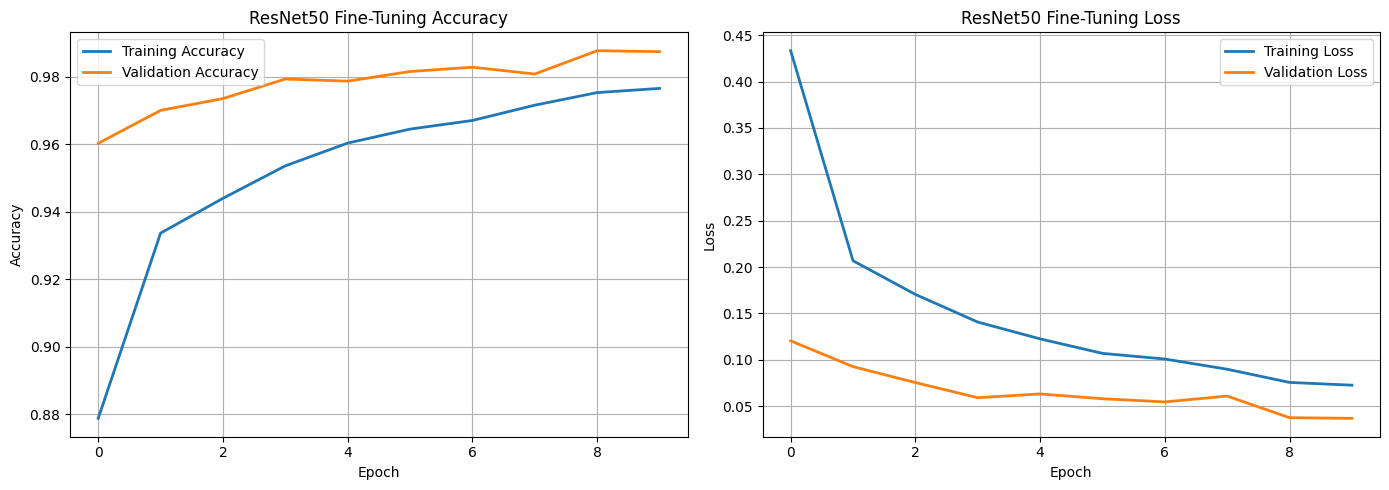

In [30]:
import matplotlib.pyplot as plt

# Accuracy Plot
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history_finetune.history['accuracy'], label='Training Accuracy', linewidth=2)
plt.plot(history_finetune.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
plt.title('ResNet50 Fine-Tuning Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history_finetune.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history_finetune.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('ResNet50 Fine-Tuning Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

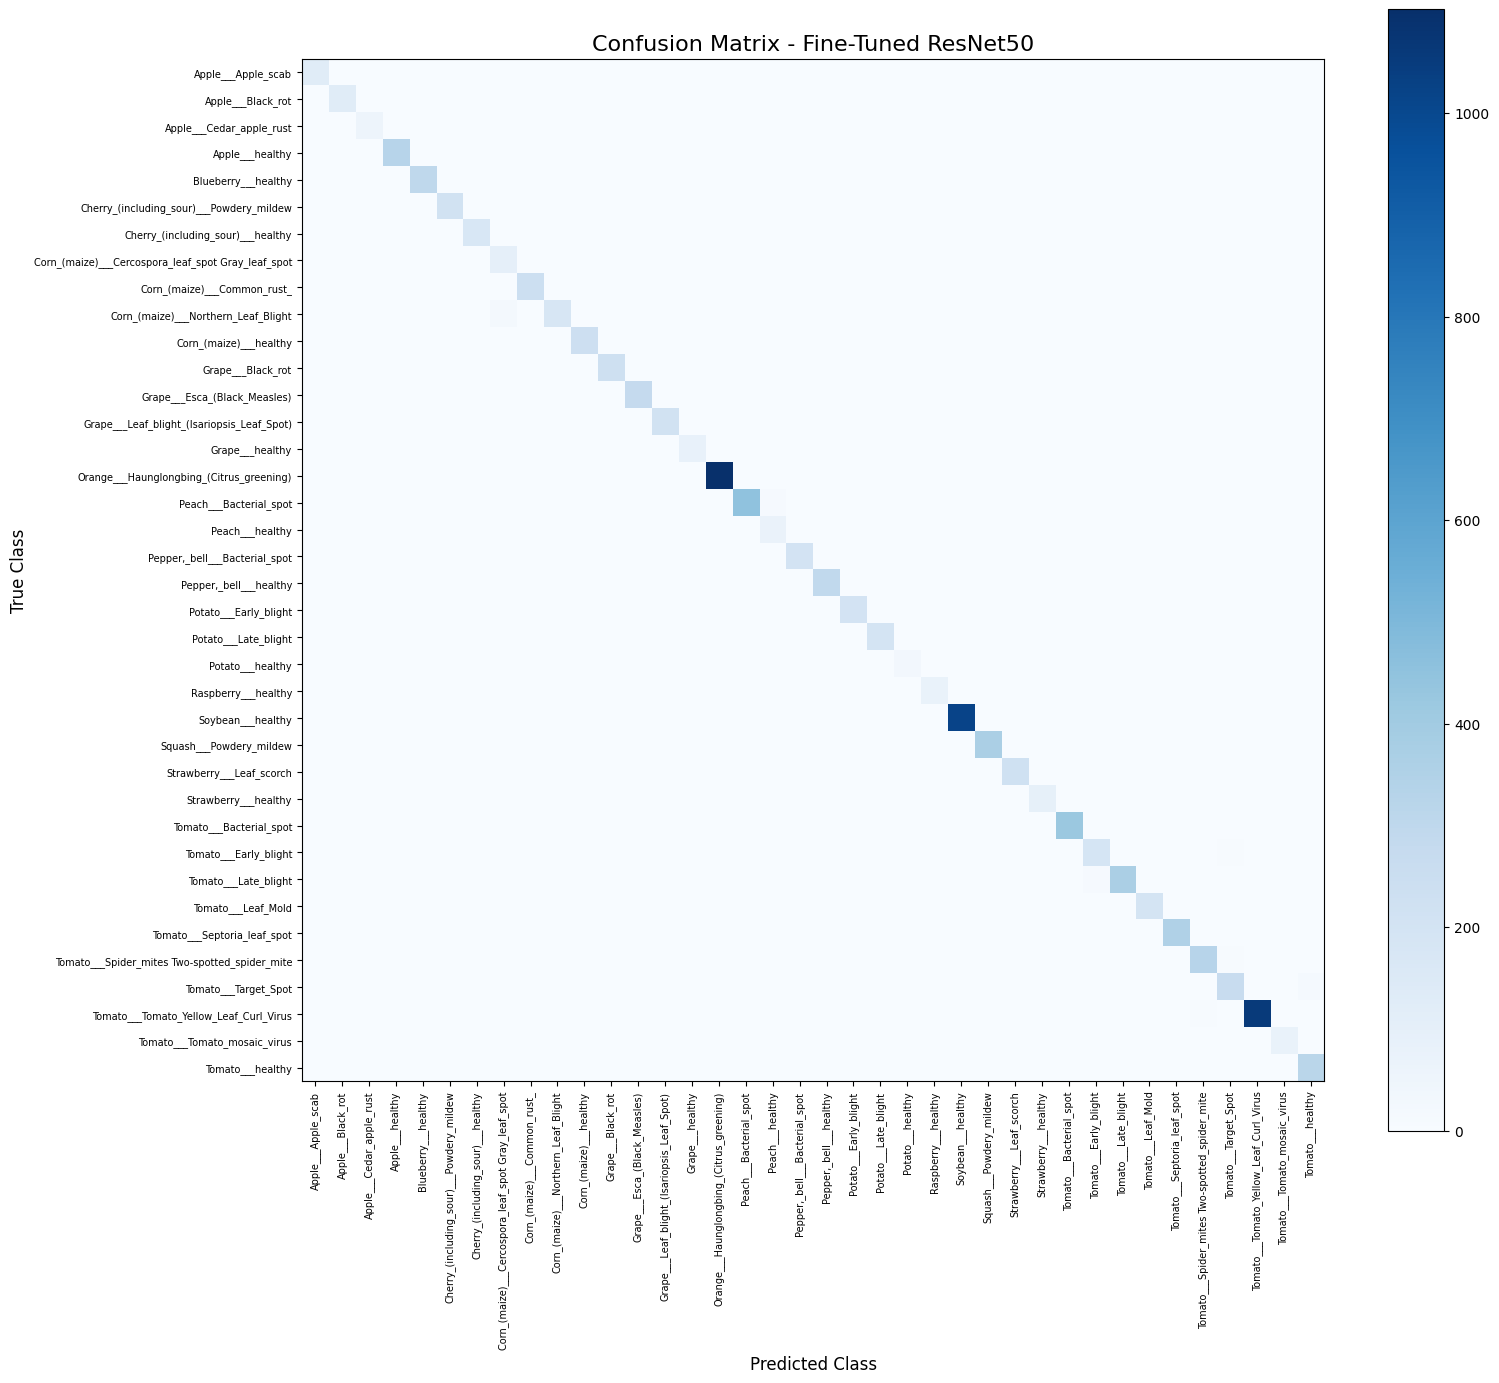

In [31]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(16, 14))
plt.imshow(cm, interpolation='nearest', cmap='Blues')

plt.title("Confusion Matrix - Fine-Tuned ResNet50", fontsize=16)
plt.colorbar()

tick_marks = np.arange(len(val_generator.class_indices))

plt.xticks(
    tick_marks,
    list(val_generator.class_indices.keys()),
    rotation=90,
    fontsize=7
)

plt.yticks(
    tick_marks,
    list(val_generator.class_indices.keys()),
    fontsize=7
)

plt.xlabel("Predicted Class", fontsize=12)
plt.ylabel("True Class", fontsize=12)

plt.tight_layout()
plt.show()

In [32]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=list(val_generator.class_indices.keys())
))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.99      0.99      0.99       126
                                 Apple___Black_rot       0.99      1.00      1.00       125
                          Apple___Cedar_apple_rust       1.00      1.00      1.00        55
                                   Apple___healthy       0.99      0.99      0.99       329
                               Blueberry___healthy       1.00      1.00      1.00       300
          Cherry_(including_sour)___Powdery_mildew       1.00      1.00      1.00       210
                 Cherry_(including_sour)___healthy       0.99      0.99      0.99       170
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.83      0.96      0.89       103
                       Corn_(maize)___Common_rust_       1.00      1.00      1.00       239
               Corn_(maize)___Northern_Leaf_Blight       0.97      0.90      0.

In [33]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Value": [
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred, average='weighted'),
        recall_score(y_true, y_pred, average='weighted'),
        f1_score(y_true, y_pred, average='weighted')
    ]
})

metrics_df

,Metric,Value
0,Accuracy,0.987386
1,Precision,0.987886
2,Recall,0.987386
3,F1-Score,0.987469


------------------------------------------------------------project done --------------------------------------------------------------------